正在读取全市场数据，请稍候...
正在过滤沪深主板数据...
正在预计算近20日涨幅(动量因子)...
开始按周执行【强势股补涨】调仓模拟...

✅ 交易明细已成功导出至: F:\self_quant\quant\回测excel\强势股补涨轮动_前300倒数10只_每周.xlsx
💰 初始本金: 50,000.00 元
💰 最终总资产: 8,473.72 元
📈 策略总收益率: -83.05%


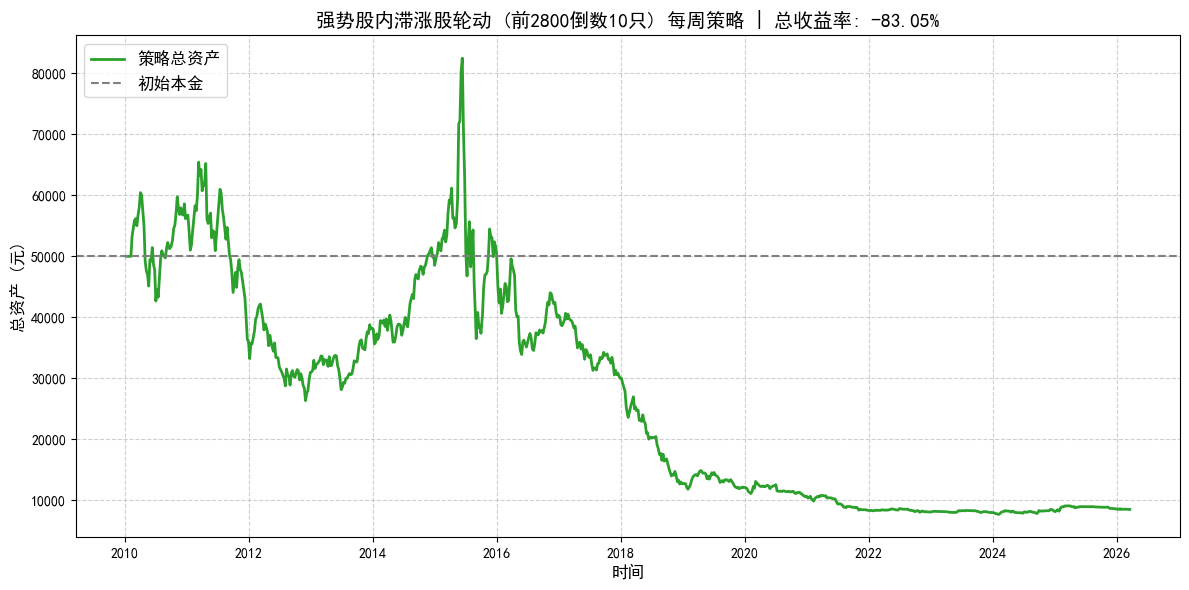

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# 设置绘图支持中文
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 第一步：配置参数与读取数据
# ==========================================
FILE_PATH = r"F:\self_quant\data\data\all_stocks_merged_fixed.parquet"
# 更改了输出文件名，方便你区分不同策略
OUTPUT_EXCEL = r"F:\self_quant\quant\回测excel\强势股补涨轮动_前300倒数10只_每周.xlsx"

INITIAL_CASH = 50000.0  # 初始本金 5万元
TARGET_STOCK_NUM = 10   # 目标持仓 10 只

print("正在读取全市场数据，请稍候...")
df = pd.read_parquet(FILE_PATH)
df['date'] = pd.to_datetime(df['date'])

# 过滤沪深主板股票
print("正在过滤沪深主板数据...")
main_board_mask = df['code'].str.contains(r'^sh\.60|^sz\.00', regex=True)
df = df[main_board_mask].copy()

# ==========================================
# 【核心新增】：预计算所有股票的近20日涨幅 (动量因子)
# ==========================================
print("正在预计算近20日涨幅(动量因子)...")
# 注意：计算历史涨幅必须先将同一只股票按时间先后排序
df.sort_values(by=['code', 'date'], inplace=True)
# shift(20) 就是当前收盘价相比 20 个交易日前的涨跌幅
df['mom_20'] = df.groupby('code')['close'].pct_change(20)

# 计算完动量后，恢复成按日期排序，以供后续按周切片回测
df.sort_values(by=['date', 'code'], inplace=True)

# 提取每周的最后一个交易日作为调仓日
df['year_week'] = df['date'].dt.to_period('W')
trade_dates = df.groupby('year_week')['date'].max().sort_values().tolist()

# ==========================================
# 第二步：定义交易费率计算函数
# ==========================================
def calculate_fees(trade_type, price, volume):
    amount = price * volume
    commission = max(5.0, amount * 0.00025)
    transfer_fee = amount * 0.00001
    stamp_duty = amount * 0.0005 if trade_type == 'sell' else 0.0
    total_fee = commission + transfer_fee + stamp_duty
    return total_fee, amount

# ==========================================
# 第三步：账户类与回测主引擎
# ==========================================
class Account:
    def __init__(self, initial_cash):
        self.cash = initial_cash
        self.positions = {}
        self.trade_logs = []
        self.history_assets = []

    def get_total_asset(self, current_date, current_prices_dict):
        stock_value = 0
        for code, pos in self.positions.items():
            price = current_prices_dict.get(code, pos['price'])
            self.positions[code]['price'] = price
            stock_value += pos['volume'] * price
        return self.cash + stock_value

account = Account(INITIAL_CASH)

print("开始按周执行【强势股补涨】调仓模拟...")

for date in trade_dates:
    daily_data = df[df['date'] == date].set_index('code')
    current_prices = daily_data['close'].to_dict()
    status_dict = daily_data['tradestatus'].to_dict()
    st_dict = daily_data['isST'].to_dict()
    pct_chg_dict = daily_data['pctChg'].to_dict()

    current_asset = account.get_total_asset(date, current_prices)
    account.history_assets.append({'date': date, 'total_asset': current_asset})

    # ---------------- 选股逻辑 ----------------
    # 【修改点】：增加条件，确保 mom_20 不为空（剔除上市不足20天的新股）
    valid_pool = daily_data[(daily_data['tradestatus'] == 1) &
                            (daily_data['isST'] == 0) &
                            (daily_data['peTTM'] > 0) &
                            (daily_data['pbMRQ'] > 0) &
                            (daily_data['mom_20'].notna())].copy()

    target_codes = []
    if len(valid_pool) >= 2800:
        # 第一步：选出近20日涨幅最大的2800只股票
        top_2800 = valid_pool.sort_values(by='mom_20', ascending=False).head(2800).copy()
        # 第二步：买入其中倒数前10只（也就是取这2800只里的最后10名）
        target_codes = top_2800.tail(TARGET_STOCK_NUM).index.tolist()
    elif len(valid_pool) >= TARGET_STOCK_NUM:
        # 容错处理：如果极端行情下全市场符合基本过滤的股票都不足2800只，就取所有合格股票的最后10名
        top_all = valid_pool.sort_values(by='mom_20', ascending=False)
        target_codes = top_all.tail(TARGET_STOCK_NUM).index.tolist()

    # ---------------- 卖出逻辑 ----------------
    current_holdings = list(account.positions.keys())
    for code in current_holdings:
        # --- 检测是否退市 ---
        if code not in daily_data.index:
            lost_vol = account.positions[code]['volume']
            last_price = account.positions[code]['price']
            loss_amount = lost_vol * last_price

            del account.positions[code]

            account.trade_logs.append({
                '日期': date, '股票代码': code, '买卖方向': '强制清理(退市)',
                '成交价': 0, '成交股数': lost_vol,
                '成交金额': 0, '交易费': 0,
                '可用现金': round(account.cash, 2),
                '总资产': round(account.get_total_asset(date, current_prices), 2),
                '备注': f'数据缺失/退市，市值计提全额亏损 {round(loss_amount, 2)}元',
                '当前实仓股票': ", ".join(list(account.positions.keys()))
            })
            continue

        if code not in target_codes:
            is_trading = status_dict.get(code, 0) == 1
            pct_chg = pct_chg_dict.get(code, 0)

            if is_trading and pct_chg > -9.3:
                sell_price = current_prices[code]
                sell_vol = account.positions[code]['volume']
                fee, amount = calculate_fees('sell', sell_price, sell_vol)

                account.cash += (amount - fee)
                del account.positions[code]

                account.trade_logs.append({
                    '日期': date, '股票代码': code, '买卖方向': '卖出',
                    '成交价': sell_price, '成交股数': sell_vol,
                    '成交金额': round(amount, 2), '交易费': round(fee, 2),
                    '可用现金': round(account.cash, 2),
                    '总资产': round(account.get_total_asset(date, current_prices), 2),
                    '备注': '常规换仓卖出',
                    '当前实仓股票': ", ".join(list(account.positions.keys()))
                })
            elif not is_trading:
                account.trade_logs.append({
                    '日期': date, '股票代码': code, '买卖方向': '卖出失败(停牌/退市)',
                    '成交价': 0, '成交股数': 0, '成交金额': 0, '交易费': 0,
                    '可用现金': round(account.cash, 2),
                    '总资产': round(account.get_total_asset(date, current_prices), 2),
                    '备注': '停牌或无交易数据，强制保留',
                    '当前实仓股票': ", ".join(list(account.positions.keys()))
                })
            elif pct_chg <= -9.3:
                account.trade_logs.append({
                    '日期': date, '股票代码': code, '买卖方向': '卖出失败(跌停)',
                    '成交价': 0, '成交股数': 0, '成交金额': 0, '交易费': 0,
                    '可用现金': round(account.cash, 2),
                    '总资产': round(account.get_total_asset(date, current_prices), 2),
                    '备注': f'跌幅 {pct_chg:.2f}% 封死跌停',
                    '当前实仓股票': ", ".join(list(account.positions.keys()))
                })

    # ---------------- 买入逻辑 ----------------
    stocks_to_buy = [code for code in target_codes if code not in account.positions]

    current_pos_count = len(account.positions)
    free_slots = max(0, TARGET_STOCK_NUM - current_pos_count)
    actual_stocks_to_buy = stocks_to_buy[:free_slots]

    if len(actual_stocks_to_buy) > 0:
        target_cash_per_stock = account.cash / len(actual_stocks_to_buy)

        for code in actual_stocks_to_buy:
            is_trading = status_dict.get(code, 0) == 1
            pct_chg = pct_chg_dict.get(code, 0)
            is_st = st_dict.get(code, 0) == 1

            if is_trading and not is_st and pct_chg < 9.3:
                buy_price = current_prices[code]
                affordable_shares = int((target_cash_per_stock * 0.997) / buy_price)
                buy_vol = (affordable_shares // 100) * 100

                if buy_vol >= 100:
                    fee, amount = calculate_fees('buy', buy_price, buy_vol)
                    if account.cash >= (amount + fee):
                        account.cash -= (amount + fee)
                        account.positions[code] = {'volume': buy_vol, 'price': buy_price}

                        # 把买入股票的20日涨幅记录在备注里，方便查阅
                        mom_val = daily_data.loc[code, 'mom_20']
                        account.trade_logs.append({
                            '日期': date, '股票代码': code, '买卖方向': '买入',
                            '成交价': buy_price, '成交股数': buy_vol,
                            '成交金额': round(amount, 2), '交易费': round(fee, 2),
                            '可用现金': round(account.cash, 2),
                            '总资产': round(account.get_total_asset(date, current_prices), 2),
                            '备注': f'强势股补涨买入 | 近20日涨幅: {mom_val:.2%}',
                            '当前实仓股票': ", ".join(list(account.positions.keys()))
                        })
            elif pct_chg >= 9.3:
                account.trade_logs.append({
                    '日期': date, '股票代码': code, '买卖方向': '买入失败(涨停)',
                    '成交价': 0, '成交股数': 0, '成交金额': 0, '交易费': 0,
                    '可用现金': round(account.cash, 2),
                    '总资产': round(account.get_total_asset(date, current_prices), 2),
                    '备注': f'涨幅 {pct_chg:.2f}% 封死涨停',
                    '当前实仓股票': ", ".join(list(account.positions.keys()))
                })

# ==========================================
# 第四步：输出结果与可视化
# ==========================================
df_trades = pd.DataFrame(account.trade_logs)
df_trades.to_excel(OUTPUT_EXCEL, index=False)
print(f"\n✅ 交易明细已成功导出至: {OUTPUT_EXCEL}")

df_assets = pd.DataFrame(account.history_assets)
df_assets.set_index('date', inplace=True)
final_asset = df_assets['total_asset'].iloc[-1]
total_return = (final_asset - INITIAL_CASH) / INITIAL_CASH * 100

print(f"💰 初始本金: {INITIAL_CASH:,.2f} 元")
print(f"💰 最终总资产: {final_asset:,.2f} 元")
print(f"📈 策略总收益率: {total_return:.2f}%")

# 绘制收益曲线
plt.figure(figsize=(12, 6))
plt.plot(df_assets.index, df_assets['total_asset'], color='#2ca02c', linewidth=2, label='策略总资产')
plt.title(f'强势股内滞涨股轮动 (前2800倒数10只) 每周策略 | 总收益率: {total_return:.2f}%', fontsize=14)
plt.xlabel('时间', fontsize=12)
plt.ylabel('总资产 (元)', fontsize=12)
plt.axhline(y=INITIAL_CASH, color='gray', linestyle='--', label='初始本金')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()